In [6]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

con = duckdb.connect('../capillary.db')

df = con.execute(""" SELECT id,gender, pid, value, auto_classification AS label FROM protein_data WHERE auto_classification = 0 OR auto_classification = 1""").df()

pids = con.execute("SELECT DISTINCT pid FROM protein_data WHERE auto_classification = 0 OR auto_classification = 1").df()

df = df[df['value'].apply(len) == 301]
df['value'] = df['value'].apply(lambda x: x[:300])

#df[ df['label'] == 2] = 1 # gör så vi även har med svaga M-komponenter.


print(f"Antal fall med M-komponent:{(df['label'] == 1).sum()}")
print(f"Antal fall utan M-komponent:{(df['label'] == 0).sum()}")
print(f"Antal fall med svag M-komponent:{(df['label'] == 2).sum()}")


con.close()


Antal fall med M-komponent:34989
Antal fall utan M-komponent:106655
Antal fall med svag M-komponent:0


In [7]:
valtrain_pids, test_pids = train_test_split(pids, test_size=0.15,random_state=25)
train_pids, val_pids = train_test_split(valtrain_pids, test_size=0.15,random_state=25)

test_rows = df[ df['pid'].isin(test_pids['pid'].tolist()) ]
val_rows = df[ df['pid'].isin(val_pids['pid'].tolist()) ]
train_rows = df[ df['pid'].isin(train_pids['pid'].tolist()) ]


male_rows   = train_rows[train_rows['gender'] == 'M']
female_rows = train_rows[train_rows['gender'] == 'K']

# Ta lika många av varje, begränsat av det minsta antalet
n = min(len(male_rows), len(female_rows))
train_rows_balanced = pd.concat([
    male_rows.sample(n, random_state=25),
    female_rows.sample(n, random_state=25)
]).sample(frac=1, random_state=25)  # shuffle

print(f"Män i träning:    {len(male_rows)}")
print(f"Kvinnor i träning:{len(female_rows)}")
print(f"Balanserad träning: {len(train_rows_balanced)} ({n} av varje)")

print(f"Antal fall med M-komponent i träningsdatan:{(train_rows_balanced['label'] == 1).sum()}")
print(f"Antal fall utan M-komponent i träningsdatan:{(train_rows_balanced['label'] == 0).sum()}")
print(f"Antal fall med M-komponent i testdatan:{(test_rows['label'] == 1).sum()}")
print(f"Antal fall utan M-komponent i testdatan:{(test_rows['label'] == 0).sum()}")

X_train = torch.tensor(np.array(train_rows_balanced['value'].tolist(), dtype=np.float32))
y_train = torch.tensor(np.array(train_rows_balanced['label'].tolist(), dtype=np.int8))

X_val = torch.tensor(np.array(val_rows['value'].tolist(), dtype=np.float32))
y_val = torch.tensor(np.array(val_rows['label'].tolist(), dtype=np.int8))

X_test = torch.tensor(np.array(test_rows['value'].tolist(), dtype=np.float32))
y_test = torch.tensor(np.array(test_rows['label'].tolist(), dtype=np.int8))

print(f"Träning:    {len(X_train):>6} ({len(X_train)/(len(df) - (np.abs(len(male_rows) - len(female_rows))) ):.0%})")
print(f"Validering: {len(X_val):>6} ({len(X_val)/(len(df) - (np.abs(len(male_rows) - len(female_rows))) ):.0%})")
print(f"Test:       {len(X_test):>6} ({len(X_test)/(len(df) - (np.abs(len(male_rows) - len(female_rows))) ):.0%})")

Män i träning:    48805
Kvinnor i träning:53306
Balanserad träning: 97610 (48805 av varje)
Antal fall med M-komponent i träningsdatan:24322
Antal fall utan M-komponent i träningsdatan:73288
Antal fall med M-komponent i testdatan:5453
Antal fall utan M-komponent i testdatan:16043
Träning:     97610 (71%)
Validering:  18037 (13%)
Test:        21496 (16%)


In [8]:
batch_sz = 512

# DataLoaders
train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_sz, shuffle=True)
val_dataloader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=batch_sz)
test_dataloader   = DataLoader(TensorDataset(X_test,   y_test),   batch_size=batch_sz)

for X, y in val_dataloader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape}")
    break

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(300, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits
    
def train(train_dataloader, model, loss_fn, optimizer):
    model.train()
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

def validate(val_dataloader, model, loss_fn):
    size = len(val_dataloader.dataset)
    num_batches = len(val_dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in val_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    return (100*correct,test_loss)

def test(test_dataloader, model, loss_fn):
    size = len(test_dataloader.dataset)
    num_batches = len(test_dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    return (100*correct,test_loss)


counts = np.bincount(y_train.numpy())
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)  # normalisera
pos_weight = torch.tensor(weights, dtype=torch.float32).to(device)

model = NeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss(weight=pos_weight)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Antal parametrar: {total_params:,}")

Shape of X: torch.Size([512, 300])
Shape of y: torch.Size([512])
Using mps device
NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=300, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=2, bias=True)
  )
)
Antal parametrar: 249,922


In [9]:
## KÖR DETTA BLOCKET FÖR ATT TRÄNA! Annars kör nästa block och läs in vikterna!
epochs = 50
accuracies = []
validation_losses = []
for t in range(epochs):
    train(train_dataloader, model, loss_fn, optimizer)
    (accuracy,avg_loss) = validate(val_dataloader, model, loss_fn)
    scheduler.step()
    print(f"Epooch {t}, accuracy: {accuracy}, Avg loss: {avg_loss}")
    accuracies.append(accuracy)
    validation_losses.append(avg_loss)
print("Done!")

torch.save(model.state_dict(), "gender_check.pth")
print("Saved PyTorch Model State to gender_check.pth")


Epooch 0, accuracy: 87.45356766646339, Avg loss: 0.45669527020719314
Epooch 1, accuracy: 88.4792371236902, Avg loss: 0.44303402718570495
Epooch 2, accuracy: 86.31147086544325, Avg loss: 0.37965674450000125
Epooch 3, accuracy: 73.78721516881966, Avg loss: 0.4455387335684564
Epooch 4, accuracy: 90.39197205743748, Avg loss: 0.32035103026363587
Epooch 5, accuracy: 89.94843931917724, Avg loss: 0.31263355538249016
Epooch 6, accuracy: 90.36979542052448, Avg loss: 0.35536472416586345
Epooch 7, accuracy: 91.88889504906581, Avg loss: 0.3274218597345882
Epooch 8, accuracy: 89.78211454232967, Avg loss: 0.45028481632471085
Epooch 9, accuracy: 91.93324832289184, Avg loss: 0.27393855734003913
Epooch 10, accuracy: 91.76692354604424, Avg loss: 0.25976650085714126
Epooch 11, accuracy: 92.52647336031491, Avg loss: 0.25116704156001407
Epooch 12, accuracy: 93.86815989355213, Avg loss: 0.23927145099474323
Epooch 13, accuracy: 93.97349891888895, Avg loss: 0.23847751464280817
Epooch 14, accuracy: 91.478627266

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load("gender_check.pth", weights_only=True))

# Samla alla prediktioner
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        all_preds.extend(pred.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Rapport
print(classification_report(all_labels, all_preds, target_names=['Negativ', 'Positiv']))

# Konfusionsmatris
print(confusion_matrix(all_labels, all_preds))

(test_accuracy, test_loss) = test(test_dataloader,model,loss_fn)
print(f"Resultat på testdatan: accuracy: {test_accuracy}, Avg loss: {test_loss}")


              precision    recall  f1-score   support

     Negativ       0.97      0.97      0.97     16043
     Positiv       0.92      0.91      0.92      5453

    accuracy                           0.96     21496
   macro avg       0.95      0.94      0.94     21496
weighted avg       0.96      0.96      0.96     21496

[[15635   408]
 [  498  4955]]
Resultat på testdatan: accuracy: 95.78526237439524, Avg loss: 0.16019912844612486


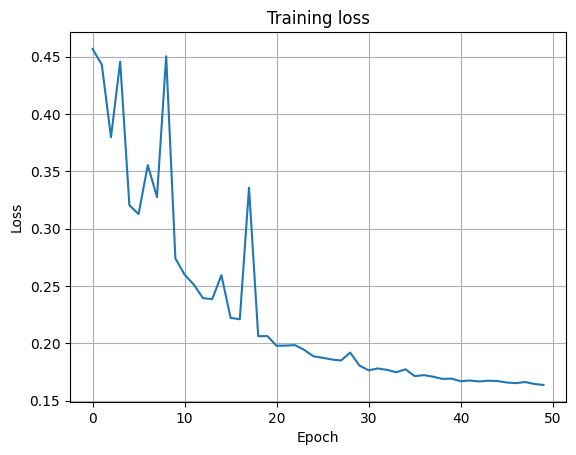

In [11]:
# Analys av hur träningen gick
import matplotlib.pyplot as plt

plt.plot(validation_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')
plt.grid(True)
plt.show()